In this lab we will discuss some basic mechanisms of knowledge representation and reasoning using Bayesian Reasoning and Bayesian Networks.  We will use pgmpy python package. Install it using the following command

In [1]:
!pip install pgmpy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 23.2 MB/s eta 0:00:00


Refer to [bnlearn](https://www.bnlearn.com/bnrepository/) website where you can find a lot of different Bayesian Networks (BNs) that can be easily imported into pgmpy as simply as this:



```
from pgmpy.utils import get_example_model
bn = get_example_model("BN name from bnlearn")
```



Let's consider the following example of Bayesian Network known as ASIA. It describes toy scenario of possible reasons and consequences of tuberculosis.

# Getting familiar with Bayesian Network structure in pgmpy

## Existing BN (ASIA)

In [2]:
import networkx as nx
from pgmpy.utils import get_example_model
bn = get_example_model("asia")

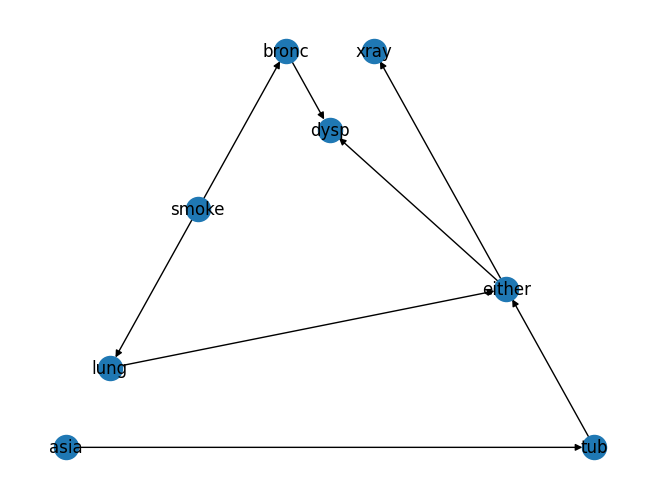

In [3]:
pos = nx.planar_layout(bn) #planar_layout option shows the BN avoiding arcs crossing
nx.draw(bn, with_labels=True, pos=pos)

We have just imported it into pgmpy-object. Now, let's have a closer look at it using more user-friendly visualisation.

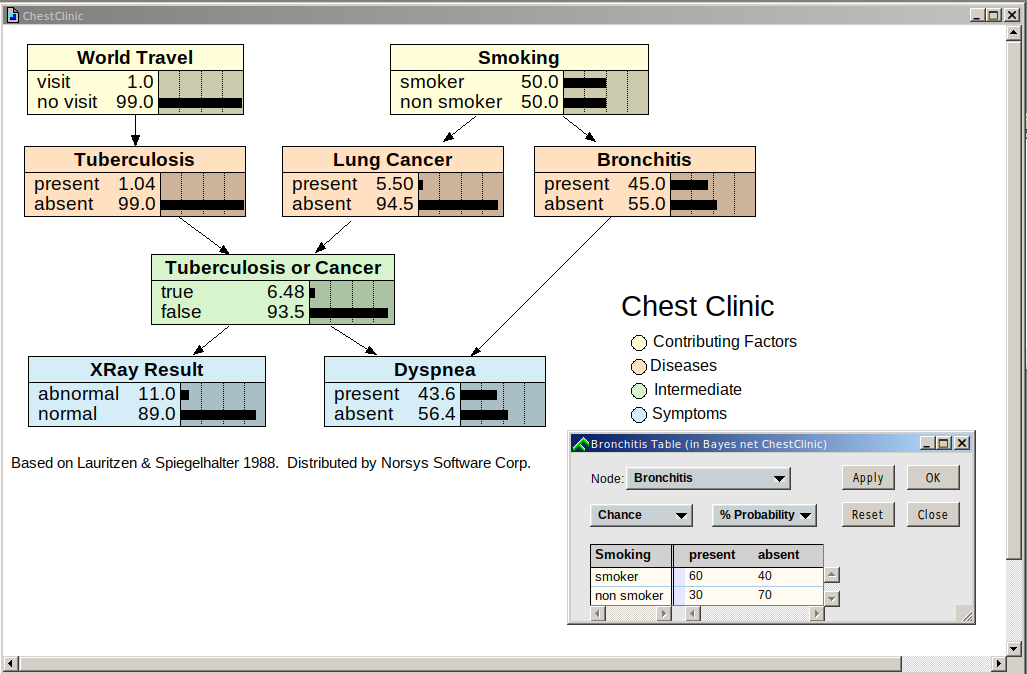

The BNs consist of nodes or variables (World Travel, Tuberculosis, Lung Cancer, and others), arcs or edges (arrows connecting the nodes) and Conditional Probability Tables (CPT) encoding the probabilistic relations between the nodes (on the screenshot above we can see the CPT for the node Bronchitis).

Now let's access to all of the named parts of the BN through `pgmpy` object

In [4]:
bn.nodes # list of nodes

NodeView(('asia', 'tub', 'smoke', 'lung', 'bronc', 'either', 'xray', 'dysp'))

In [5]:
bn.states # dict of nodes and corresponding states

{'asia': ['yes', 'no'],
 'smoke': ['yes', 'no'],
 'bronc': ['yes', 'no'],
 'either': ['yes', 'no'],
 'dysp': ['yes', 'no'],
 'lung': ['yes', 'no'],
 'tub': ['yes', 'no'],
 'xray': ['yes', 'no']}

In [6]:
bn.edges # list of edges/arcs

OutEdgeView([('asia', 'tub'), ('tub', 'either'), ('smoke', 'lung'), ('smoke', 'bronc'), ('lung', 'either'), ('bronc', 'dysp'), ('either', 'xray'), ('either', 'dysp')])

In [7]:
bn.cpds # list of all CPTs

[<TabularCPD representing P(asia:2) at 0x7bd20864f140>,
 <TabularCPD representing P(bronc:2 | smoke:2) at 0x7bd2088034a0>,
 <TabularCPD representing P(dysp:2 | bronc:2, either:2) at 0x7bd20864f8c0>,
 <TabularCPD representing P(either:2 | lung:2, tub:2) at 0x7bd20864f080>,
 <TabularCPD representing P(lung:2 | smoke:2) at 0x7bd20864fc20>,
 <TabularCPD representing P(smoke:2) at 0x7bd20864e510>,
 <TabularCPD representing P(tub:2 | asia:2) at 0x7bd20864fc50>,
 <TabularCPD representing P(xray:2 | either:2) at 0x7bd20864fce0>]

In [9]:
print(bn.cpds[0])

+-----------+------+
| asia(yes) | 0.01 |
+-----------+------+
| asia(no)  | 0.99 |
+-----------+------+


In [11]:
print(bn.cpds[2])

+-----------+-------------+------------+-------------+------------+
| bronc     | bronc(yes)  | bronc(yes) | bronc(no)   | bronc(no)  |
+-----------+-------------+------------+-------------+------------+
| either    | either(yes) | either(no) | either(yes) | either(no) |
+-----------+-------------+------------+-------------+------------+
| dysp(yes) | 0.9         | 0.8        | 0.7         | 0.1        |
+-----------+-------------+------------+-------------+------------+
| dysp(no)  | 0.1         | 0.2        | 0.3         | 0.9        |
+-----------+-------------+------------+-------------+------------+


Refer to https://github.com/pgmpy/pgmpy/blob/dev/pgmpy/factors/discrete/CPD.py#L18 to learn more about CPTs

In [15]:
bn.cpds[6].variable

'tub'

In [16]:
bn.cpds[6].variable_card # variable cardinality - number of values of node/variable. Bronc could be yes or no, so we have 2 here

2

In [17]:
bn.cpds[6].values # the exact values of CPT

array([[0.05, 0.01],
       [0.95, 0.99]])

In [19]:
bn.cpds[6].state_names

{'asia': ['yes', 'no'], 'tub': ['yes', 'no']}

## Inference in BNs

Inferencing the BN could be described as asking it a question about certain "target" variable bearing in mind that we know something about other variables.

In [20]:
from pgmpy.inference import VariableElimination
belief_propagation = VariableElimination(bn)

Let's ask about the probability of bronchitis if we know that the patient does not smoke and he/she has lung cancer

In [21]:
result = belief_propagation.query(variables=["bronc"],# target variable - the node we ask the question about
                                    evidence = {"smoke": "no", "lung":"yes"},# what we know about the "patient"
                                    show_progress=False)
p = result.get_value(**{"bronc":"yes"})# when the updated probability is calculated, we may check the probability of the exact state we are interested in
p

np.float64(0.3)

We may also check what was the probability of bronchitis without other knowledge

In [22]:
result = belief_propagation.query(variables=["bronc"],# target variable - the node we ask the question about
                                    evidence = {},# assume we know nothing specific about the patient
                                    show_progress=False)
p = result.get_value(**{"bronc":"yes"})# when the updated probability is calculated, we may check the probability of the exact state we are interested in
p

np.float64(0.44999999999999996)

Refer to https://github.com/pgmpy/pgmpy/blob/dev/examples/Inference%20in%20Discrete%20Bayesian%20Networks.ipynb for more examples of BN inference

# Creating your own Bayesian Network with pgmpy

## "AND" BN

In [23]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete.CPD import TabularCPD

Now let's create our own simple BN. For simplicity, let's consider so called AND network -  it has a $A\rightarrow C \leftarrow B$ structure, where the probabilities of $A$ and $B$ nodes are evenly distributed, and $C$ is true iff $A$ and $B$ are true.

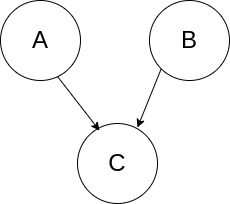

In [24]:
AND_BN = DiscreteBayesianNetwork([('A', 'C'), ('B', 'C')]) # Initializing the BN with the edges

Note that we have just created a BN and defined its structure. There are different ways of adding edges and nodes. You can learn more about this in the documentation - https://pgmpy.org/models/bayesiannetwork.html

In [35]:
cpd_a = TabularCPD(variable = 'A', # the name of the node, we create the CPT for
                   variable_card = 2, # variable cardinality - how many states the node has
                   values = [[0.8],[0.2]], # the values of CPT
                   state_names={'A': ['False', 'True']}
                   )
cpd_b = TabularCPD(variable = 'B',
                   variable_card = 2,
                   values = [[0.6], [0.4]],
                   state_names={'B': ['False', 'True']}

                   ) # creating the root nodes, which are not dependent on other nodes

We have defined the root nodes above. It is pretty straightforward.
At the same time, you should be more carefull when defining the CPTs of the nodes which have the incoming edges

In [36]:
cpd_c = TabularCPD(
                  variable='C', # the name of the node, we create the CPT for
                   variable_card=2, # variable cardinality - how many states the node has
                    values= [[1,1, 1,0], # the values of CPT
                              [0,0, 0,1]],
                    evidence=['A', 'B'], # List of variables in evidences (if any) w.r.t. which CPD is defined - the precise order is very important because it affects the intepreation of the values in the array
                    evidence_card=[2, 2],# cardinality of the evidence nodes in the same order as you set them in "evidence"
                  state_names={'A': ['False', 'True'],
                               'B': ['False', 'True'],
                               'C':['False', 'True']}
                  )

In [37]:
print(cpd_c) # AND network, C is true iff A and B are true

+----------+----------+----------+----------+---------+
| A        | A(False) | A(False) | A(True)  | A(True) |
+----------+----------+----------+----------+---------+
| B        | B(False) | B(True)  | B(False) | B(True) |
+----------+----------+----------+----------+---------+
| C(False) | 1.0      | 1.0      | 1.0      | 0.0     |
+----------+----------+----------+----------+---------+
| C(True)  | 0.0      | 0.0      | 0.0      | 1.0     |
+----------+----------+----------+----------+---------+


In [38]:
AND_BN.add_cpds(cpd_a, cpd_b, cpd_c)# adding the composed CPTs into the BN

In [39]:
AND_BN.check_model()# internal check of the consistency of a BN

True

## Inference on the created BN

In [40]:
belief_propagation_and = VariableElimination(AND_BN)

In [41]:
result = belief_propagation_and.query(variables=["C"],
                                    evidence = {"A":"True", "B":"False"},
                                    show_progress=False)
p = result.get_value(**{"C":"True"})
p

np.float64(0.0)

In [42]:
result = belief_propagation_and.query(variables=["C"],
                                    evidence = {"A":"True", "B":"True"},
                                    show_progress=False)
p = result.get_value(**{"C":"True"})
p

np.float64(1.0)

In [43]:
result = belief_propagation_and.query(variables=["C"],
                                    evidence = {"A":"True"},
                                    show_progress=False)
p = result.get_value(**{"C":"True"})
p

np.float64(0.4)

# Exercises

## Useful resources for the exercises


[BN creation examples](https://github.com/pgmpy/pgmpy/blob/dev/examples/Creating%20a%20Discrete%20Bayesian%20Network.ipynb)

[BN inference examples](https://github.com/pgmpy/pgmpy/blob/dev/examples/Inference%20in%20Discrete%20Bayesian%20Networks.ipynb)

Documentation of [BayesianNetwork class](https://pgmpy.org/models/bayesiannetwork.html)

Source code of [BayesianNetwork class](https://github.com/pgmpy/pgmpy/blob/dev/pgmpy/models/BayesianNetwork.py)

Source code of [CPT class](https://github.com/pgmpy/pgmpy/blob/dev/pgmpy/factors/discrete/CPD.py#L18)

### Building the Bayesian Network

We start building the Conditional Probability Tables (CPTs) for each one of the variables/nodes present in the Bayesian Network (BN). To do so we use the probabilities given in the

**Copy**:

In [ ]:
cpd_copy = TabularCPD(variable = 'copy',
                      variable_card = 2,
                      values = [[0.999], [0.001]],
                      state_names = {'copy': ['False', 'True']})
print(cpd_copy)

+-------------+-------+
| copy(False) | 0.999 |
+-------------+-------+
| copy(True)  | 0.001 |
+-------------+-------+


**Study**:

In [ ]:
cpd_study = TabularCPD(variable = 'study',
                      variable_card = 2,
                      values = [[0.1], [0.9]],
                      state_names = {'study': ['False', 'True']})
print(cpd_study)

+--------------+-----+
| study(False) | 0.1 |
+--------------+-----+
| study(True)  | 0.9 |
+--------------+-----+


In [ ]:
cpd_pass = TabularCPD(variable='pass',
                      variable_card=2,
                      values=[[0.99, 0.05, 0.5, 0.03],
                              [0.01, 0.95, 0.5, 0.97]],
                      evidence=['copy', 'study'],
                      evidence_card=[2,2],
                      state_names={'pass': ['False', 'True'],
                                  'copy': ['False', 'True'],
                                  'study': ['False', 'True']}
                  )
print(cpd_pass)

+-------------+--------------+-------------+--------------+-------------+
| copy        | copy(False)  | copy(False) | copy(True)   | copy(True)  |
+-------------+--------------+-------------+--------------+-------------+
| study       | study(False) | study(True) | study(False) | study(True) |
+-------------+--------------+-------------+--------------+-------------+
| pass(False) | 0.99         | 0.05        | 0.5          | 0.03        |
+-------------+--------------+-------------+--------------+-------------+
| pass(True)  | 0.01         | 0.95        | 0.5          | 0.97        |
+-------------+--------------+-------------+--------------+-------------+


In [ ]:
cpd_job = TabularCPD(variable='job',
                      variable_card=2,
                      values=[[0.925, 0.25],
                              [0.075, 0.75]],
                      evidence=['pass'],
                      evidence_card=[2],
                      state_names={'job': ['False', 'True'],
                                  'pass': ['False', 'True']}
                  )
print(cpd_job)

+------------+-------------+------------+
| pass       | pass(False) | pass(True) |
+------------+-------------+------------+
| job(False) | 0.925       | 0.25       |
+------------+-------------+------------+
| job(True)  | 0.075       | 0.75       |
+------------+-------------+------------+


In [ ]:
cpd_degree = TabularCPD(variable='degree',
                      variable_card=2,
                      values=[[1, 0.15],
                              [0.0, 0.85]],
                      evidence=['pass'],
                      evidence_card=[2],
                      state_names={'degree': ['False', 'True'],
                                  'pass': ['False', 'True']}
                  )
print(cpd_degree)

+---------------+-------------+------------+
| pass          | pass(False) | pass(True) |
+---------------+-------------+------------+
| degree(False) | 1.0         | 0.15       |
+---------------+-------------+------------+
| degree(True)  | 0.0         | 0.85       |
+---------------+-------------+------------+


In [ ]:
students_bn = DiscreteBayesianNetwork([
    ('copy', 'pass'),
    ('study', 'pass'),
    ('pass', 'job'),
    ('pass', 'degree')
])
print(students_bn.edges)

[('copy', 'pass'), ('pass', 'job'), ('pass', 'degree'), ('study', 'pass')]


In [ ]:
students_bn.add_cpds(cpd_copy, cpd_study, cpd_pass, cpd_job, cpd_degree)
students_bn.check_model()

True

Construct BN corresponding to the example in Palma and Marín (pp. 229-230):

_A student will obtain his/her degree if he/she passes a subject. He/she has a better chance of getting a job if he/she proves that he/she has knowledge of the subject he/she has to pass. The student can pass the subject by studying or copying._

The following probabilities are known:

```
P(Copy=true)=0.001, P(Study=true)=0.9

P(Pass=true/ Copy=true, Study=true)=0.97

P(Pass=true/ Copy=true, Study=false)=0.50

P(Pass=true/ Copy=false, Study=true)=0.95

P(Pass=true/ Copy=false, Study=false)=0.01

P(Job=true/Pass=true)=0.75, P(Job=true/Pass=false)=0.075

P(Degre=true/Pass=true)=0.85, P(Degree=true/Pass=false)=0
```

Check experimentally on the graph the d-independence condition in the following cases of basic patterns:



* serial pattern: studying influences the achievement of the degree, but both facts are independent once you have passed (or not) the course.
* divergent pattern: knowing that the student is working is independent of whether he/she has completed his/her degree once it is known that he/she has passed (or not) the course
* convergent pattern: whether he/she passed (or failed) the course, the fact that he/she did not study affects the credibility of his/her having copied


In the three cases, verify the change in the influence of the variables for the two values (TRUE, FALSE) of the variable responsible for the separation.

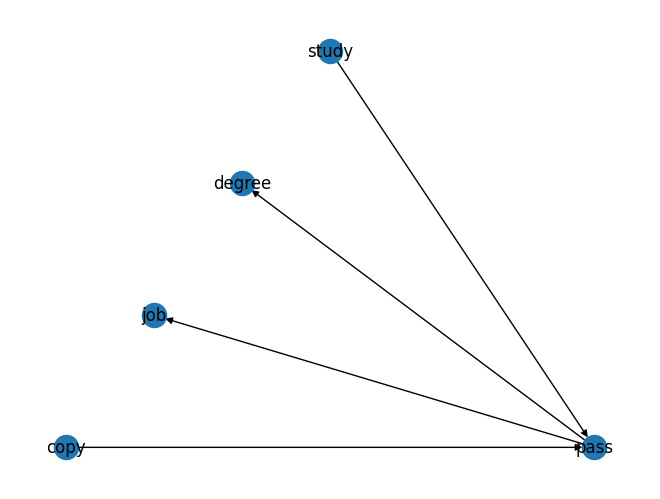

In [ ]:
pos = nx.planar_layout(students_bn)
nx.draw(students_bn, with_labels=True, pos=pos)

## Exercise 1

Using pgmpy, create a small BN that will help you with the following exercise (6.5 of the reference Palma and Marín, p. 255) and answer the question:

_After an Internet connection session, the computer tests positive in an antivirus test for the presence of a particular type of virus. The type of test performed is 98% correct if the system contains that type of virus. A false positive for that virus is set at 5%. If we as users know that the system has been infected in 0.1% of the connections, what is the posterior probability that the system is infected after a positive antivirus test?_

First, let's interpret this as conditional probabilities

```
P(Virus=true) = 0.001

P(Antivirus alarm=true / Virus=true) = 0.98
P(Antivirus alarm=false / Virus=true) = 0.02

P(Antivirus alarm=true / Virus=false) = 0.05
P(Antivirus alarm=false / Virus=false)= 0.95

```


Now, for better visualization let's make a CPTs from these probabilities  

| Virus (false) |  0.999 |
|---|---|
| Virus (true) | 0.001 |

|                         | Virus (false) | Virus (true) |
|:-----------------------:|---------------|--------------|
| Antivirus alarm (false) |        0.95       |       0.02       |
| Antivirus alarm (true)  |        0.05       |       0.98       |

## Exercise 3

Create a BN of the following form, corresponding to the example 2.5.2 of the Korb and Nicholson book



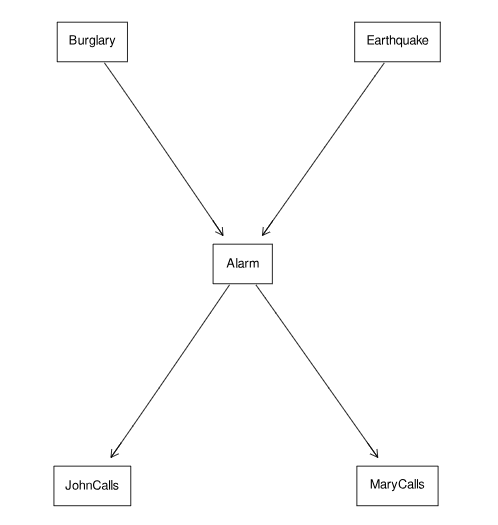

 Check the influence on the credibility of whether there has been a burglary or earthquake in the following cases:

 * The alarm goes off, but neither John nor Mary is calling.

* The alarm does not sound and also...

1. John and Mary call

2. John calls but Mary does not

* There is an earthquake and in addition...

1. Alarm sounds

2. The alarm does not sound, but John and Mary call.

Tip: check [bnlearn](https://www.bnlearn.com/bnrepository/), it may save you some time

## Exercise 4

Create a BN for the case described in exercise 2.8.2 of the Korb and Nicholson book: "Fred's LISP Dilemma".

_Fred is debugging a LISP program. He has typed a statement in the LISP interpreter and the interpreter does not respond to any further keystrokes. The cursor does not appear on the screen. Normally the cursor blinks, indicating that the interpreter is waiting for a new statement to be entered. Fred knows that there are only two possible causes for the cursor not appearing: i) computer hardware problem (the hardware is very reliable: it fails only 1% of the time) or ii) his code is wrong (this happens 40% of the time). Fred has at the same time a text editor open, which will work correctly as long as there is no hardware failure. The editor also has a cursor, which blinks when the editor is running._

The model should not use more than 6 variables. The following is requested for this model:

* obtain the belief of each variable before adding any evidence.

* obtain the new belief about the fact "Fred's code is wrong" having added the evidence that the LISP cursor has not been displayed.

* assuming that Fred checks on the screen that the editor cursor is blinking, how does this affect his belief that his code is erroneous.

## Exercise 5

Create a BN described in exercise 2.8.3 of the reference Korb and Nicholson: "A Lecturer's Life":

_Dr. Nicholson spends about 60% of her working hours in the office and the rest elsewhere. She has the light off 50% of the time when she is in the office. When she goes out, she usually leaves the light on 5% of the time. 80% of the time she is in the office, she opens a session on the computer, but she also opens remote sessions from home (10% of the time when she is not in the office)._

On the model constructed, assess the following situation: to what extent does the belief that the office light is on changes if it has been verified that Dr. Nicholson is connected to the computer.

## Exercise 6

### 6.1

 Create a BN corresponding to the example in Figure 2.1 (p. 31) of the Korb and Nicholson book. The following is requested for this network:

* diagnostic reasoning: obtain the belief of having cancer for a patient with dyspnea.

* predictive reasoning: to obtain the change in the belief of having cancer and dyspnea for a smoker patient who has not undergone diagnostic tests.

* intercausal reasoning: to obtain the change in belief in the following cases:

1. of having been exposed to environmental pollution for two smoking patients, one of whom has developed cancer and one of whom has not.  

2. of being a smoker for two patients who have been exposed to environmental pollution, one of whom has developed cancer and one of whom has not.  

Tip: again check [bnlearn](https://www.bnlearn.com/bnrepository/), it may save you some time

### 6.2

Follow step by step the execution of the Kim and Pearl algorithm on the previous example, for the no set evidences case. Compare your results with the ones you get with pgmpy.

### 6.3.

Follow step by step the execution of the Kim and Pearl algorithm on the model described in Fig. 3.2 (p.60) in the Korb and Nicholson book for the following cases:

* No evidences

* Mary calls

Compare your results in both cases with the ones you get with pgmpy.

# Evaluation and deliverables

* Deliverable of this part consists on a written report of exercise 6 and your version of the notebook with the code of tasks completion.

* The work will be carried out compulsorily in teams of TWO people, whenever possible.  

* The deadline for the delivery of this practice is **11th March 2026 23:59**.

* After this deadline each group may be called to a face-to-face session, for a short discussion with the group members about the submitted deliverable and the results therein reported.

* The evaluation process will include the delivered materials (ipython notebook with the code and quality of the submitted report) as well as the discussion of the face-to-face session.  

* Finally, we kindly remind you that the total or partial copying of the materials between different groups or from another source will automatically lead to qualification of 0 in the course.

# Other useful links

## Other BN packages

Python

* Pomerganate
* PyAgrum
* PyBN
* Sorobn
* PyBNesian  
* PyMC3



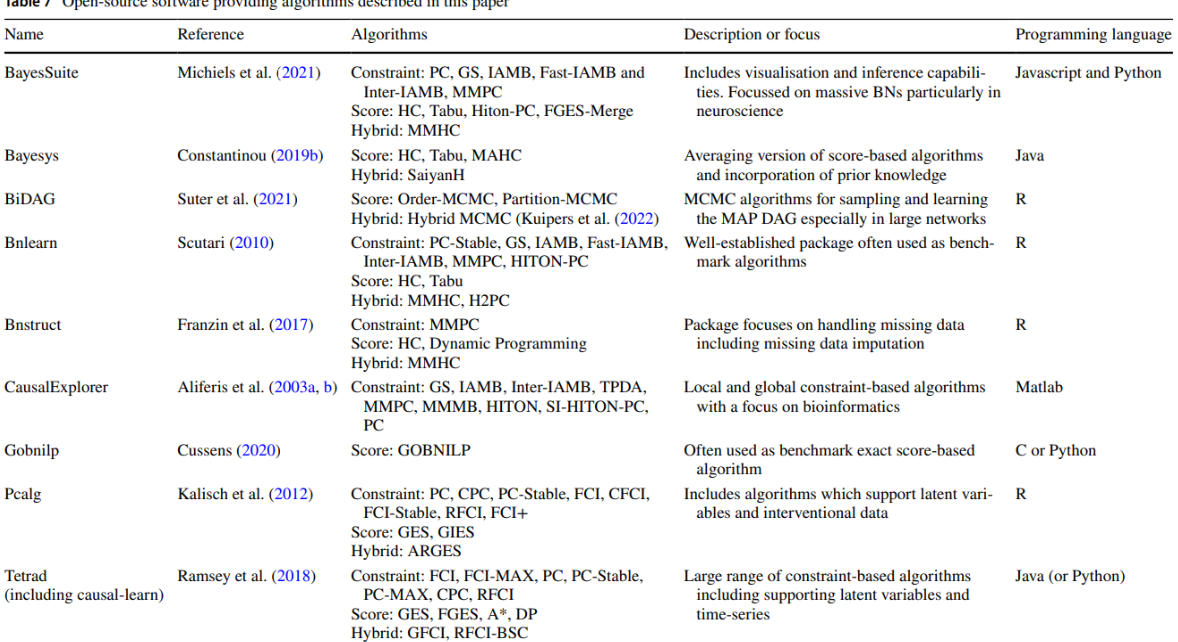

https://bayesian-intelligence.com/software/

## Sources of the BNs

* https://www.bnlearn.com/bnrepository/  

* https://online.bayesserver.com/

* https://bayesian-ai.eecs.qmul.ac.uk/bayesys/

* http://repo.bayesfusion.com/  

* https://forum.hugin.com/index.php/board,12.0.html  

* https://www.cs.huji.ac.il/w~galel/Repository/  

* https://bndg.cs.aau.dk/html/bayesian_networks.html  

* https://www.norsys.com/netlibrary/index.htm